In [225]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

class LinearRegression:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self, X, y):
        # Add intercept term as a column of ones
        X = np.column_stack((np.ones(X.shape[0]), X))
        # Use the pseudo-inverse to avoid singular matrix issues
        theta = np.linalg.pinv(X) @ y
        self.intercept_ = theta[0]
        self.coef_ = theta[1:]
        
    def predict(self, X):
        return self.intercept_ + X @ self.coef_


In [226]:
class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, *, value=None):
        self.feature_index = feature_index # index of the feature used for splitting
        self.threshold = threshold # threshold value for the split
        self.left = left # left subtree
        self.right = right # right subtree
        self.value = value # value for a leaf node (mean of target)

In [227]:
class DecisionTreeRegressor:
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = None

    # Using sklearn's MSE to evaluate splits
    def _mse(self, y):
        # Compare y to its mean
        return mean_squared_error(y, np.full_like(y, y.mean()))
    
    def _best_split(self, X, y):
        # Initialize
        best_mse = float("inf")
        best_idx, best_thr = None, None
        n_samples, n_features = X.shape
        
        for feature_index in range(n_features):
            # Sort data along the feature
            sorted_idx = np.argsort(X[:, feature_index])
            sorted_X = X[sorted_idx, feature_index]
            sorted_y = y[sorted_idx]
            
            # Loop over candidate thresholds (midpoints between consecutive unique values)
            for i in range(1, n_samples):
                if sorted_X[i] == sorted_X[i-1]:
                    continue  # skip if no change in feature value
                threshold = (sorted_X[i] + sorted_X[i-1]) / 2.0
                
                left_mask = X[:, feature_index] <= threshold
                right_mask = X[:, feature_index] > threshold
                
                # Enforce only the minimum leaf condition
                if (np.sum(left_mask) < self.min_samples_leaf or 
                    np.sum(right_mask) < self.min_samples_leaf):
                    continue
                
                y_left = y[left_mask]
                y_right = y[right_mask]
                mse_left = self._mse(y_left)
                mse_right = self._mse(y_right)
                mse_split = (len(y_left) * mse_left + len(y_right) * mse_right) / n_samples
                
                if mse_split < best_mse:
                    best_mse = mse_split
                    best_idx = feature_index
                    best_thr = threshold
        
        return best_idx, best_thr, best_mse

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape

        # Stop if not enough samples to split into two valid leaves or if the node is pure (one class)
        if n_samples < 2 * self.min_samples_leaf or np.unique(y).shape[0] == 1:
            return Node(value=np.mean(y))
        
        # Only check depth if max_depth is specified
        if self.max_depth is not None and depth >= self.max_depth:
            return Node(value=np.mean(y))
        
        # Compute parent's MSE and determine best split
        parent_mse = self._mse(y)
        feature_index, threshold, split_mse = self._best_split(X, y)
        
        # If no valid split is found or the split doesn't reduce error, create a leaf
        if feature_index is None or split_mse >= parent_mse:
            return Node(value=np.mean(y))
        
        left_mask = X[:, feature_index] <= threshold
        right_mask = X[:, feature_index] > threshold
        
        # Even after a valid split, ensure that both sides have enough samples
        if np.sum(left_mask) < self.min_samples_leaf or np.sum(right_mask) < self.min_samples_leaf:
            return Node(value=np.mean(y))
        
        left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        return Node(feature_index=feature_index, threshold=threshold, left=left, right=right)
    
    def fit(self, X, y):
        self.root = self._build_tree(X, y, 0)
    
    def _predict_sample(self, node, x):
        if node.value is not None:
            return node.value
        if x[node.feature_index] <= node.threshold:
            return self._predict_sample(node.left, x)
        else:
            return self._predict_sample(node.right, x)
    
    def predict(self, X):
        return np.array([self._predict_sample(self.root, x) for x in X])


In [228]:
# "Beacon Markers" are the laptime
def load_csv_with_beacon_markers(file_path):
    with open(file_path, 'r', newline='') as f:
        reader = csv.reader(f)
        
        lap_markers = None
        headers = None
        data = []
        skip_units_line = False
        
        for row in reader:
            # Skip empty rows
            if not row or all(not cell.strip() for cell in row):
                continue
            
            # Look for the row starting with "Beacon Markers"
            if row[0].strip() == "Beacon Markers":
                marker_str = " ".join(row[1:])
                marker_tokens = marker_str.split()
                lap_markers = [float(x) for x in marker_tokens]
            
            # Look for the header row that starts with "Time"
            elif row[0].strip() == "Time":
                headers = row
                skip_units_line = True  # Next row is the units row
                continue
            
            # Skip the units row (immediately after the header)
            elif skip_units_line:
                skip_units_line = False
                continue
            
            # Once headers are found, all other rows are telemetry data
            elif headers is not None:
                if len(row) == len(headers):
                    data.append(row)
                    
        if lap_markers is None:
            raise ValueError("Could not find a row starting with 'Beacon Markers'")
        if headers is None:
            raise ValueError("Could not find a telemetry header row starting with 'Time'")
        
        df = pd.DataFrame(data, columns=headers)
        for col in df.columns:
            # Replace any non-numeric values with NaN (there shouldnt be any anyway)
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        return lap_markers, df


In [229]:
def aggregate_lap_data(df, lap_markers):
    lap_features = [] # Holds feature means
    lap_targets = [] # Holds computed lap times of each lap
    prev_time = 0.0 # Start time of each lap (starts at 0)
    
    for lap_end in lap_markers:
        # Only include the rows where the "Time" is between the previous lap marker and the current lap marker
        lap_df = df[(df["Time"] >= prev_time) & (df["Time"] <= lap_end)]
        if lap_df.empty:
            print(f"=== No telemetry data found between {prev_time} and {lap_end} ===")
            prev_time = lap_end
            continue
        
        features = {} # Holds the mean of each feature for the current lap
        for col in df.columns:
            # !!! Time is not a feature !!!
            if col != "Time":
                features[col] = lap_df[col].mean()
        
        lap_features.append(features)
        lap_duration = lap_end - prev_time
        lap_targets.append(lap_duration)
        prev_time = lap_end

    # Create a DataFrame for the lap features
    lap_summary = pd.DataFrame(lap_features)
    # Make a new column called LapTime
    lap_summary["LapTime"] = lap_targets
    return lap_summary


=== Linear Regression ===
Mean Squared Error: 24.54472950927557
Coefficients:
Distance: -0.0001
LAP_BEACON: 0.0000
G_LAT: 0.0006
ROTY: 0.0060
STEERANGLE: -0.0655
SPEED: -0.2417
THROTTLE: -0.3248
BRAKE: 0.0488
GEAR: -0.0077
G_LON: 0.0025
CLUTCH: 0.1214
RPMS: -0.0194
TC: -0.0039
ABS: 0.0004
SUS_TRAVEL_LF: -0.0481
SUS_TRAVEL_RF: -0.0235
SUS_TRAVEL_LR: -0.0084
SUS_TRAVEL_RR: 0.0017
BRAKE_TEMP_LF: -0.2001
BRAKE_TEMP_RF: 0.0665
BRAKE_TEMP_LR: 0.0969
BRAKE_TEMP_RR: 0.0696
TYRE_PRESS_LF: 0.0233
TYRE_PRESS_RF: 0.0586
TYRE_PRESS_LR: 0.0116
TYRE_PRESS_RR: -0.0017
TYRE_TAIR_LF: 0.0556
TYRE_TAIR_RF: -0.0593
TYRE_TAIR_LR: -0.1349
TYRE_TAIR_RR: -0.1897
WHEEL_SPEED_LF: -0.0633
WHEEL_SPEED_RF: -0.0633
WHEEL_SPEED_LR: -0.0765
WHEEL_SPEED_RR: -0.0766
BUMPSTOPUP_RIDE_LF: -0.0047
BUMPSTOPUP_RIDE_RF: 0.0002
BUMPSTOPUP_RIDE_LR: 0.0000
BUMPSTOPUP_RIDE_RR: -0.0001
BUMPSTOPDN_RIDE_LF: -0.0002
BUMPSTOPDN_RIDE_RF: -0.0011
BUMPSTOPDN_RIDE_LR: -0.0004
BUMPSTOPDN_RIDE_RR: 0.0032
BUMPSTOP_FORCE_LF: 0.0960
BUMPSTOP_F

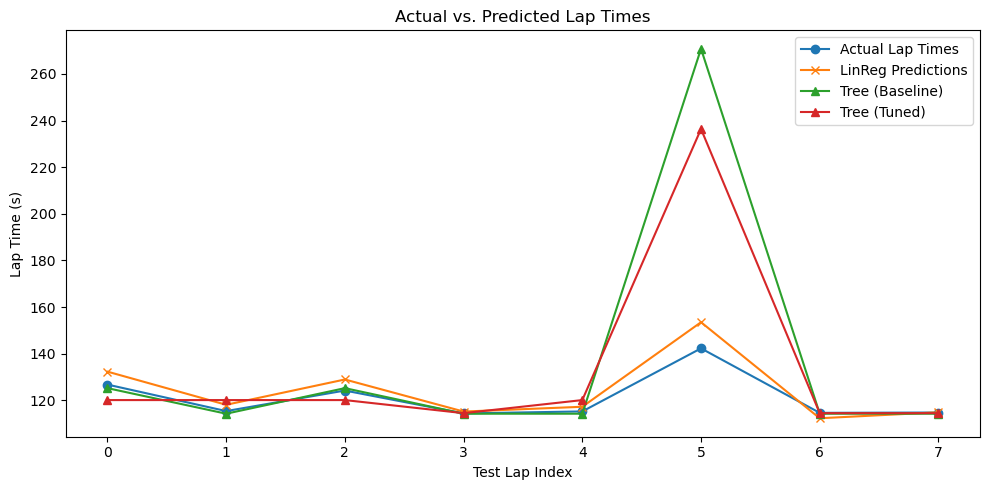

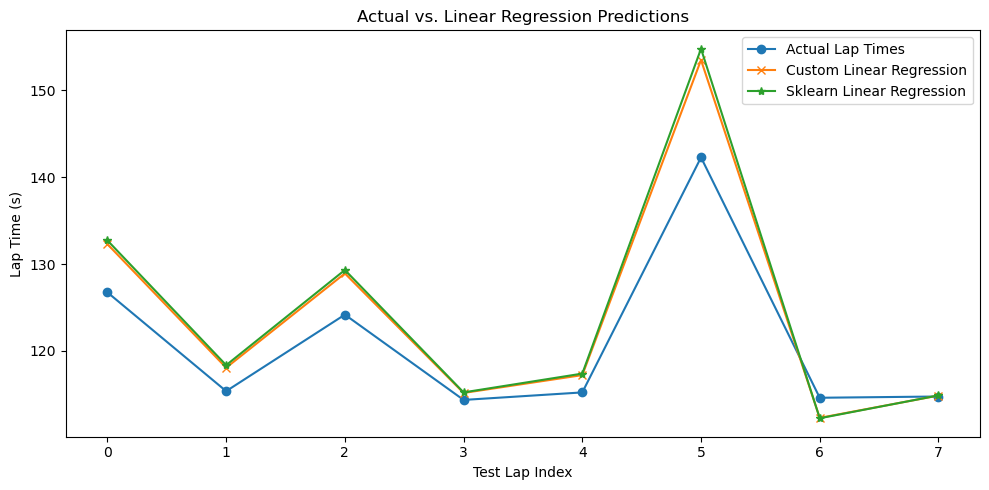

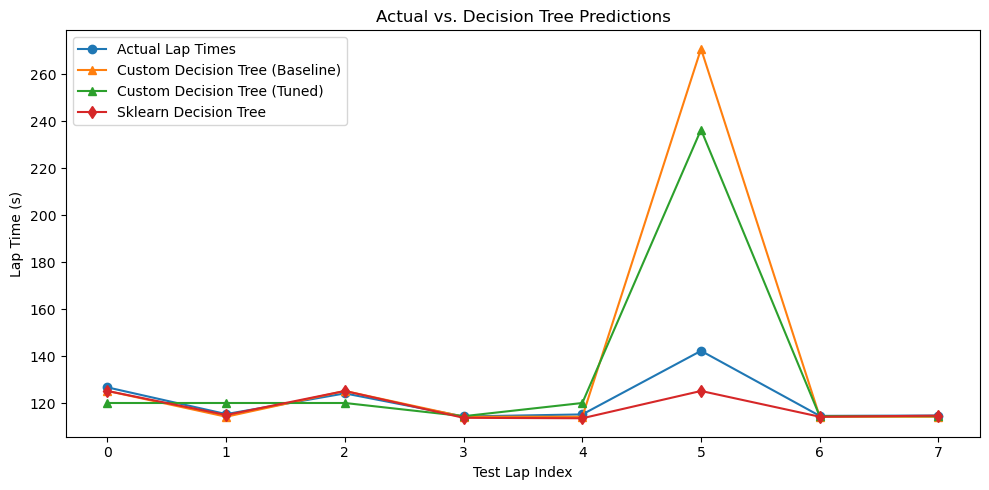


=== Comparison of Predictions ===
Lap  0 | Actual: 126.74 | LinReg: 132.29 | Tree(Base): 125.21 | Tree(Tuned): 120.09
Lap  1 | Actual: 115.37 | LinReg: 118.07 | Tree(Base): 114.24 | Tree(Tuned): 120.09
Lap  2 | Actual: 124.18 | LinReg: 128.92 | Tree(Base): 125.21 | Tree(Tuned): 120.09
Lap  3 | Actual: 114.36 | LinReg: 115.17 | Tree(Base): 114.24 | Tree(Tuned): 114.47
Lap  4 | Actual: 115.23 | LinReg: 117.22 | Tree(Base): 114.24 | Tree(Tuned): 120.09
Lap  5 | Actual: 142.28 | LinReg: 153.49 | Tree(Base): 270.79 | Tree(Tuned): 236.39
Lap  6 | Actual: 114.61 | LinReg: 112.29 | Tree(Base): 114.24 | Tree(Tuned): 114.47
Lap  7 | Actual: 114.75 | LinReg: 114.86 | Tree(Base): 114.24 | Tree(Tuned): 114.47

=== scikit-learn Model Comparison ===
Sklearn Linear Regression MSE: 29.8143
Sklearn Decision Tree MSE: 37.2577


In [230]:
def main():
    # CSV File
    csv_file = "/Users/stevenchase/Downloads/monza-porsche_991ii_gt3_r-18-2025.03.12-14.59.35.csv"
    
    lap_markers, telemetry_df = load_csv_with_beacon_markers(csv_file)
    lap_summary = aggregate_lap_data(telemetry_df, lap_markers)
    
    # Separate features (X) and target (y)
    X = lap_summary.drop(columns=["LapTime"])
    y = lap_summary["LapTime"]
    
    # Convert to numpy arrays for our custom models
    X_np = X.values
    y_np = y.values
    
    # train-test split (60% train, 40% test)
    np.random.seed(42)
    indices = np.random.permutation(len(y_np))
    train_size = int(0.6 * len(y_np))
    train_idx, test_idx = indices[:train_size], indices[train_size:]
    trainX, testX = X_np[train_idx], X_np[test_idx]
    trainY, testY = y_np[train_idx], y_np[test_idx]
    
    # Linear Regression
    linreg = LinearRegression()
    linreg.fit(trainX, trainY)
    y_pred_lr = linreg.predict(testX)
    mse_lr = mean_squared_error(testY, y_pred_lr)
    print("\n=== Linear Regression ===")
    print("Mean Squared Error:", mse_lr)
    print("Coefficients:")
    for col, coef in zip(X.columns, linreg.coef_):
        print(f"{col}: {coef:.4f}")
    
    # Baseline Decision Tree
    # Tree parameters are the same for scikit
    tree_reg = DecisionTreeRegressor(max_depth=None, min_samples_split=2, min_samples_leaf=1)
    tree_reg.fit(trainX, trainY)
    y_pred_tree = tree_reg.predict(testX)
    mse_tree = mean_squared_error(testY, y_pred_tree)
    print("\n=== Decision Tree (Baseline) ===")
    print("Mean Squared Error:", mse_tree)
    
    # Hyperparameter Tuning
    # Simple grid search over a few parameter values
    max_depth_values = [None, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    min_samples_split_values = [2, 5, 10, 20]
    min_samples_leaf_values = [1, 2, 5]

    best_mse = float("inf")
    best_params = (None, 2, 1)  # default placeholders

    for md in max_depth_values:
        for mss in min_samples_split_values:
            for msl in min_samples_leaf_values:
                # Initialize and train
                dt_candidate = DecisionTreeRegressor(
                    max_depth=md,
                    min_samples_split=mss,
                    min_samples_leaf=msl
                )
                dt_candidate.fit(trainX, trainY)
                # Evaluate
                y_pred_candidate = dt_candidate.predict(testX)
                mse_candidate = mean_squared_error(testY, y_pred_candidate)
                
                # Check if this is the best so far
                if mse_candidate < best_mse:
                    best_mse = mse_candidate
                    best_params = (md, mss, msl)
    
    print("\n=== Hyperparameter Tuning Results ===")
    print(f"Best MSE on test set: {best_mse:.4f}")
    print(f"Best parameters: max_depth={best_params[0]}, "
          f"min_samples_split={best_params[1]}, "
          f"min_samples_leaf={best_params[2]}")

    # Re-train final model with best params
    best_md, best_mss, best_msl = best_params
    best_tree = DecisionTreeRegressor(
        max_depth=best_md,
        min_samples_split=best_mss,
        min_samples_leaf=best_msl
    )
    best_tree.fit(trainX, trainY)
    y_pred_best_tree = best_tree.predict(testX)
    final_mse = mean_squared_error(testY, y_pred_best_tree)
    print(f"\n=== Final Tuned Decision Tree ===")
    print(f"Mean Squared Error: {final_mse:.4f}")

    # Plot Actual vs Predicted times
    plt.figure(figsize=(10, 5))
    indices_plot = np.arange(len(testY))
    plt.plot(indices_plot, testY, label="Actual Lap Times", marker='o')
    plt.plot(indices_plot, y_pred_lr, label="LinReg Predictions", marker='x')
    plt.plot(indices_plot, y_pred_tree, label="Tree (Baseline)", marker='^')
    plt.plot(indices_plot, y_pred_best_tree, label="Tree (Tuned)", marker='^')
    plt.xlabel("Test Lap Index")
    plt.ylabel("Lap Time (s)")
    plt.title("Actual vs. Predicted Lap Times")
    plt.legend()
    plt.tight_layout()
    plt.show()

    from sklearn.linear_model import LinearRegression as SklearnLR
    from sklearn.tree import DecisionTreeRegressor as SklearnDTR
    
    # Train and predict with scikit-learn's Linear Regression
    sk_lr = SklearnLR()
    sk_lr.fit(trainX, trainY)
    y_pred_sk_lr = sk_lr.predict(testX)
    
    # Train and predict with scikit-learn's Decision Tree
    sk_dtr = SklearnDTR(random_state=42)
    sk_dtr.fit(trainX, trainY)
    y_pred_sk_dtr = sk_dtr.predict(testX)
    
    # Plot for Linear Regression: Actual vs. Custom Linear Regression and scikit-learn Linear Regression Predictions
    plt.figure(figsize=(10, 5))
    indices_plot = np.arange(len(testY))
    plt.plot(indices_plot, testY, label="Actual Lap Times", marker='o')
    plt.plot(indices_plot, y_pred_lr, label="Custom Linear Regression", marker='x')
    plt.plot(indices_plot, y_pred_sk_lr, label="Sklearn Linear Regression", marker='*')
    plt.xlabel("Test Lap Index")
    plt.ylabel("Lap Time (s)")
    plt.title("Actual vs. Linear Regression Predictions")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Plot for Decision Trees: Actual vs. Custom Baseline, Custom Tuned, and scikit-learn Decision Tree Predictions
    plt.figure(figsize=(10, 5))
    indices_plot = np.arange(len(testY))
    plt.plot(indices_plot, testY, label="Actual Lap Times", marker='o')
    plt.plot(indices_plot, y_pred_tree, label="Custom Decision Tree (Baseline)", marker='^')
    plt.plot(indices_plot, y_pred_best_tree, label="Custom Decision Tree (Tuned)", marker='^')
    plt.plot(indices_plot, y_pred_sk_dtr, label="Sklearn Decision Tree", marker='d')
    plt.xlabel("Test Lap Index")
    plt.ylabel("Lap Time (s)")
    plt.title("Actual vs. Decision Tree Predictions")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print a quick comparison
    print("\n=== Comparison of Predictions ===")
    for i, (actual, lr_pred, tree_pred, tuned_pred) in enumerate(
        zip(testY, y_pred_lr, y_pred_tree, y_pred_best_tree)
    ):
        print(f"Lap {i:2d} | Actual: {actual:.2f} | LinReg: {lr_pred:.2f} | "
              f"Tree(Base): {tree_pred:.2f} | Tree(Tuned): {tuned_pred:.2f}")

    from sklearn.linear_model import LinearRegression as SklearnLR
    from sklearn.tree import DecisionTreeRegressor as SklearnDTR
    
    # Train scikit-learn Linear Regression
    mse_lr = mean_squared_error(testY, y_pred_sk_lr)
    
    # Train scikit-learn Decision Tree Regressor
    mse_dtr = mean_squared_error(testY, y_pred_sk_dtr)
    
    # Print a simple statement with their MSE values
    print("\n=== scikit-learn Model Comparison ===")
    print(f"Sklearn Linear Regression MSE: {mse_lr:.4f}")
    print(f"Sklearn Decision Tree MSE: {mse_dtr:.4f}")

if __name__ == "__main__":
    main()